# Brain Age Prediction: MS patients - Longitudinal analysis

This notebook investigates how brain age gap (BAG) changes over time in MS patients.

The analysis includes predictions from both the unsmoothed and smoothed brain age models, and compares several BAG measures:

- Raw BAG
- Bias-corrected BAG
- Residual BAG
- Adjusted BAG

The main aim is to assess whether the brain age measures show a systematic longitudinal trend across follow-up sessions.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from scipy import stats

In [2]:
# Define project paths
project_path = Path("/Users/anneaasengen/MS_project")
pred_path = project_path / "Prediksjoner" 
smooth_pred_path = project_path / "prediksjoner_smoothed"
dato_csv = project_path / "Metadata_OFAMS" / "dato.csv"

In [3]:
# Load prediction files from the unsmoothed model
# One CSV file is loaded for each time point
df_bl = pd.read_csv(pred_path / "MS_brain_age_predictions_baseline.csv")
df_m1 = pd.read_csv(pred_path / "MS_brain_age_predictions_m1.csv")
df_m6 = pd.read_csv(pred_path / "MS_brain_age_predictions_m6.csv")
df_m12 = pd.read_csv(pred_path / "MS_brain_age_predictions_m12.csv")
df_m24 = pd.read_csv(pred_path / "MS_brain_age_predictions_m24.csv")
df_m120 = pd.read_csv(pred_path / "MS_brain_age_predictions_m120.csv")

df_dato = pd.read_csv(dato_csv) # Info about symptom and disease duration

In [4]:
# Load prediction files from the smoothed model
df_sm_bl = pd.read_csv(smooth_pred_path / "smoothed_MS_brain_age_predictions_baseline.csv")
df_sm_m1 = pd.read_csv(smooth_pred_path / "smoothed_MS_brain_age_predictions_m1.csv")
df_sm_m6 = pd.read_csv(smooth_pred_path / "smoothed_MS_brain_age_predictions_m6.csv")
df_sm_m12 = pd.read_csv(smooth_pred_path / "smoothed_MS_brain_age_predictions_m12.csv")
df_sm_m24 = pd.read_csv(smooth_pred_path / "smoothed_MS_brain_age_predictions_m24.csv")
df_sm_m120 = pd.read_csv(smooth_pred_path / "smoothed_MS_brain_age_predictions_m120.csv")

## Longitudinal dataframe

The prediction files are first converted into a common long-format structure. Each row represents one subject at one time point.

In [5]:
# Add time information to each dataframe
# Time is given in months from baseline.

# Unsmoothed model
df_bl["time"] = 0
df_m1["time"] = 1
df_m6["time"] = 6
df_m12["time"] = 12
df_m24["time"] = 24
df_m120["time"] = 120 # 10 year follow up after original trial ended (corresponds to 12 years after baseline)

# Smoothed model
df_sm_bl["time"] = 0
df_sm_m1["time"] = 1
df_sm_m6["time"] = 6
df_sm_m12["time"] = 12
df_sm_m24["time"] = 24
df_sm_m120["time"] = 120

In [6]:
# Standardize column names across time points
# The age and EDSS columns have different names in the original files depending on session
# They are renamed to common names so that all time points can later be combined

# Baseline
df_bl_long = df_bl.rename(columns={"age_BL": "age","EDSS_BL": "EDSS"}).copy()
df_sm_bl_long = df_sm_bl.rename(columns={"age_BL": "age","EDSS_BL": "EDSS"}).copy()

# Month 1
df_m1_long = df_m1.rename(columns={"age_m1": "age"}).copy()
df_m1_long["EDSS"] = pd.NA  # no EDSS info for month 1
df_m1_long["edss_group"] = pd.NA

df_sm_m1_long = df_sm_m1.rename(columns={"age_m1": "age"}).copy()
df_sm_m1_long["EDSS"] = pd.NA  # no EDSS info for month 1
df_sm_m1_long["edss_group"] = pd.NA

# Month 6
df_m6_long = df_m6.rename(columns={"age_m6": "age","EDSS_m6": "EDSS"}).copy()
df_sm_m6_long = df_sm_m6.rename(columns={"age_m6": "age","EDSS_m6": "EDSS"}).copy()

# Month 12
df_m12_long = df_m12.rename(columns={"age_m12": "age","EDSS_m12": "EDSS"}).copy()
df_sm_m12_long = df_sm_m12.rename(columns={"age_m12": "age","EDSS_m12": "EDSS"}).copy()

# Month 24
df_m24_long = df_m24.rename(columns={"age_m24": "age","EDSS_m24": "EDSS"}).copy()
df_sm_m24_long = df_sm_m24.rename(columns={"age_m24": "age","EDSS_m24": "EDSS"}).copy()

# Month 120 
df_m120_long = df_m120.rename(columns={"age_10Yrs": "age","EDSS_10Yrs": "EDSS"}).copy()
df_sm_m120_long = df_sm_m120.rename(columns={"age_10Yrs": "age","EDSS_10Yrs": "EDSS"}).copy()

In [7]:
# Define the columns that should be kept in the longitudinal dataframes
# Keeping the same variables in every dataframe makes it possible to concatenate them

common_cols = ["participant_id","time","sex","age", "EDSS","predicted_age", "brain_age_gap","predicted_age_bc","brain_age_gap_bc","edss_group"]

df_bl_long = df_bl_long[common_cols]
df_m1_long = df_m1_long[common_cols]
df_m6_long = df_m6_long[common_cols]
df_m12_long = df_m12_long[common_cols]
df_m24_long = df_m24_long[common_cols]
df_m120_long = df_m120_long[common_cols]

df_sm_bl_long = df_sm_bl_long[common_cols]
df_sm_m1_long = df_sm_m1_long[common_cols]
df_sm_m6_long = df_sm_m6_long[common_cols]
df_sm_m12_long = df_sm_m12_long[common_cols]
df_sm_m24_long = df_sm_m24_long[common_cols]
df_sm_m120_long = df_sm_m120_long[common_cols]

In [8]:
# Combine all time points into one longitudinal dataframe for each model

# Unsmoothed model
df_long = pd.concat([df_bl_long, df_m1_long, df_m6_long, df_m12_long, df_m24_long, df_m120_long],ignore_index=True)
# Sort by participant and time to make each subject's trajectory ordered correctly
df_long = df_long.sort_values(["participant_id", "time"]).reset_index(drop=True)

# Smoothed model
df_sm_long = pd.concat([df_sm_bl_long, df_sm_m1_long, df_sm_m6_long, df_sm_m12_long, df_sm_m24_long, df_sm_m120_long],ignore_index=True)
df_sm_long = df_sm_long.sort_values(["participant_id", "time"]).reset_index(drop=True)

/var/folders/h4/p2m1_4912rl2zkhg65_yw78h0000gn/T/ipykernel_8107/1357139736.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat([df_bl_long, df_m1_long, df_m6_long, df_m12_long, df_m24_long, df_m120_long],ignore_index=True)
/var/folders/h4/p2m1_4912rl2zkhg65_yw78h0000gn/T/ipykernel_8107/1357139736.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sm_long = pd.concat([df_sm_bl_long, df_sm_m1_long, df_sm_m6_long, df_sm_m12_long, df_sm_m24_long, df_sm_m120_long],ignore_index

In [9]:
# Add disease duration and symptom duration to the longitudinal dataframes

# Select relevant metadata columns and rename them to match the longitudinal dataframe
df_dato_subset = df_dato[['Patnr', 'DISEASE_DURATION', 'SYMPTOM_DURATION']].copy()
df_dato_subset = df_dato_subset.rename(columns={'Patnr': 'participant_id','DISEASE_DURATION': 'disease_duration','SYMPTOM_DURATION': 'symptom_duration'})

# Merge duration information into both longitudinal dataframes
df_long = df_long.merge(df_dato_subset, on='participant_id', how='left')
df_sm_long = df_sm_long.merge(df_dato_subset, on='participant_id', how='left')

# Update duration variables for each time point
# The original duration variables refer to baseline
# Sympton/disease duration are in years
# Since time is measured in months, time/12 converts time to years
df_long['disease_duration_time'] = (df_long['disease_duration'] + df_long['time'] / 12)
df_long['symptom_duration_time'] = (df_long['symptom_duration'] + df_long['time'] / 12)
df_sm_long['disease_duration_time'] = (df_sm_long['disease_duration'] + df_sm_long['time'] / 12)
df_sm_long['symptom_duration_time'] = (df_sm_long['symptom_duration'] + df_sm_long['time'] / 12)

In [10]:
# Replace the original baseline duration columns with the time-updated duration columns
# This means that disease_duration and symptom_duration now refer to the estimated duration
# at the specific session, not only at baseline.


# Unsmoothed model
df_long = df_long.drop(columns=['symptom_duration'])
df_long = df_long.rename(columns={'symptom_duration_time': 'symptom_duration'})
df_long = df_long.drop(columns=['disease_duration'])
df_long = df_long.rename(columns={'disease_duration_time': 'disease_duration'})

# Smoothed model
df_sm_long = df_sm_long.drop(columns=['symptom_duration'])
df_sm_long = df_sm_long.rename(columns={'symptom_duration_time': 'symptom_duration'})
df_sm_long = df_sm_long.drop(columns=['disease_duration'])
df_sm_long = df_sm_long.rename(columns={'disease_duration_time': 'disease_duration'})

In [11]:
df_long.head()

,participant_id,time,sex,age,EDSS,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,disease_duration,symptom_duration
0,101,0,F,35.00,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,0.000000,2.000000
1,101,1,F,35.08,NaN,38.153460,3.073461,38.525620,3.445620,NaN,0.083333,2.083333
2,101,6,F,35.50,2.0,42.360916,6.860916,42.683376,7.183376,mild,0.500000,2.500000
3,101,12,F,36.00,2.0,37.604240,1.604240,37.982887,1.982887,mild,1.000000,3.000000
4,101,24,F,37.00,2.0,41.782860,4.782860,42.112150,5.112148,mild,2.000000,4.000000


In [12]:
df_sm_long.head()

,participant_id,time,sex,age,EDSS,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,disease_duration,symptom_duration
0,101,0,F,35.00,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,0.000000,2.000000
1,101,1,F,35.08,NaN,32.854310,-2.225691,33.554516,-1.525484,NaN,0.083333,2.083333
2,101,6,F,35.50,2.0,45.781870,10.281872,46.289124,10.789124,mild,0.500000,2.500000
3,101,12,F,36.00,2.0,30.176420,-5.823580,31.385036,-4.614964,mild,1.000000,3.000000
4,101,24,F,37.00,2.0,41.214910,4.214909,41.790325,4.790325,mild,2.000000,4.000000


## Plot: BAG over time

The following function visualizes how BAG changes over time.

Each thin line represents one subject. The thicker fitted line shows the overall linear trend across all available observations.

In [13]:
def plot_bag_over_time_flexible(df_unsmooth,df_smooth=None,cols=None,labels=None,model_name="",y_label="",time_limit=120,ylim=(-30, 50)):

    """
    Plot brain age measures over time.

    The function can be used in two ways:

    1. If two columns are given, it compares two BAG variants within the same model
       for example raw BAG vs bias-corrected BAG.

    2. If one column is given together with both unsmoothed and smoothed dataframes,
       it compares the same BAG measure between the unsmoothed and smoothed models.

    Each thin line represents one participant's trajectory across available time points.
    The orange line is a simple linear fit across all observations and is included
    as a visual summary of the overall trend.
    """

    # Case 1: raw vs bias-corrected BAG measures within ine model
    if len(cols) == 2:

        # Restrict data to the selected follow-up period
        df_plot = df_unsmooth[df_unsmooth["time"] <= time_limit]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Loop through the two selected BAG columns
        for ax, col, label in zip(axes, cols, labels):

            # Add horizontal reference line at zero BAG
            ax.axhline(0, color="red", linestyle="--")

            # Plot one line per participant
            for pid, group in df_plot.groupby("participant_id"):
                group = group.sort_values("time")
                mask = group["time"].notna() & group[col].notna()
                if mask.any():
                    ax.plot(group.loc[mask, "time"], group.loc[mask, col], alpha=0.2)

            # Select valid observations for the overall linear fit
            mask = df_plot["time"].notna() & df_plot[col].notna()
            x = df_plot.loc[mask, "time"]
            y = df_plot.loc[mask, col]

            # Fit and plot a simple linear trend line for visualization
            if len(x) > 1:
                a, b = np.polyfit(x, y, 1)
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = a * x_fit + b

                ax.plot(x_fit, y_fit, linewidth=3, color="#1f77b4",
                        label=f"Fit: y = {a:.3f}x + {b:.2f}")

            # Figure formatting
            ax.set_title(f"{model_name}, {label}")
            ax.set_xlabel("Time (months)")
            ax.set_ylabel(y_label)
            ax.set_xlim(0, time_limit)
            ax.set_ylim(*ylim)
            ax.legend()

    # Case 2: Compare unsmoothed and smoothed models for one BAG measure
    elif len(cols) == 1:

        # Restrict both dataframes to the selected follow-up period
        df_u = df_unsmooth[df_unsmooth["time"] <= time_limit]
        df_s = df_smooth[df_smooth["time"] <= time_limit]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot the same BAG measure for unsmoothed and smoothed models
        for ax, df_plot, label in zip(axes, [df_u, df_s], ["Unsmoothed", "Smoothed"]):
            col = cols[0]

            ax.axhline(0, color="red", linestyle="--")

            # Plot individual subject trajectories
            for pid, group in df_plot.groupby("participant_id"):
                group = group.sort_values("time")
                mask = group["time"].notna() & group[col].notna()
                if mask.any():
                    ax.plot(group.loc[mask, "time"], group.loc[mask, col], alpha=0.2)

            # Fit linear trend for visualization
            mask = df_plot["time"].notna() & df_plot[col].notna()
            x = df_plot.loc[mask, "time"]
            y = df_plot.loc[mask, col]

            if len(x) > 1:
                a, b = np.polyfit(x, y, 1)
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = a * x_fit + b

                ax.plot(x_fit, y_fit, linewidth=3, color="#1f77b4",
                        label=f"Fit: y = {a:.3f}x + {b:.2f}")

            # Figure formatting
            ax.set_title(label)
            ax.set_xlabel("Time (months)")
            ax.set_ylabel(y_label)
            ax.set_xlim(0, time_limit)
            ax.set_ylim(*ylim)
            ax.legend()

    else:
        raise ValueError("cols must have length 1 or 2")

    # Add shared figure title and display plot
    plt.suptitle(f"{y_label} over time (0–{time_limit} months)", fontsize=16)
    plt.tight_layout()
    plt.show()

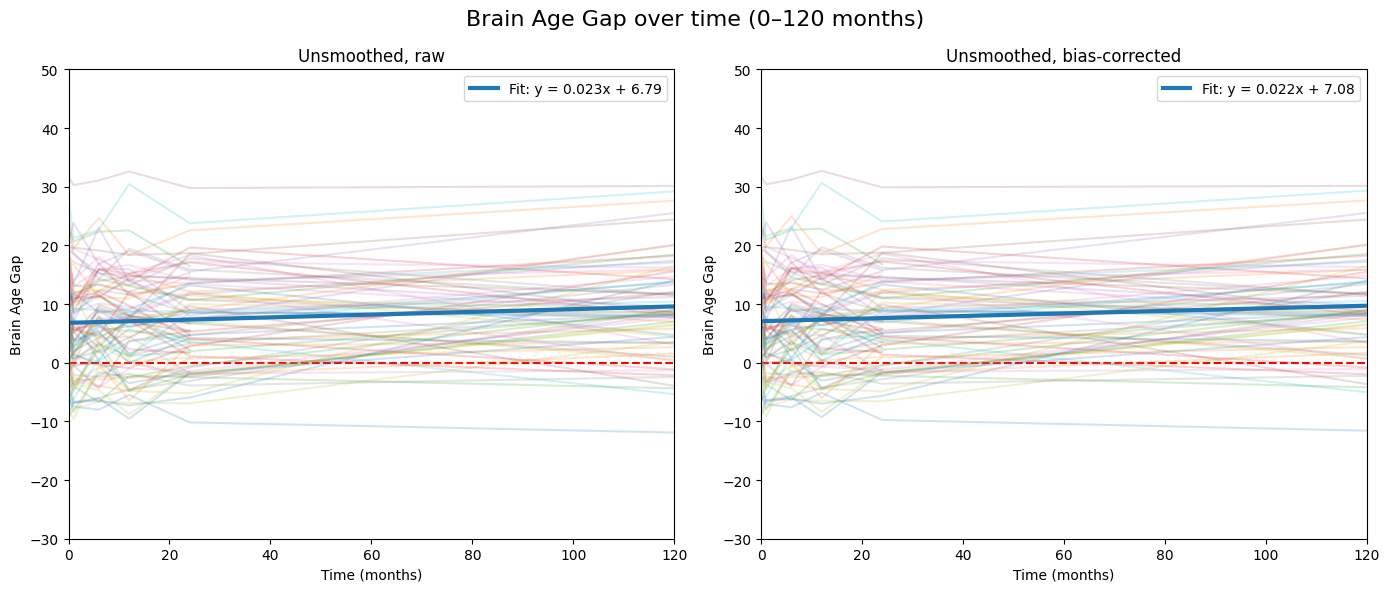

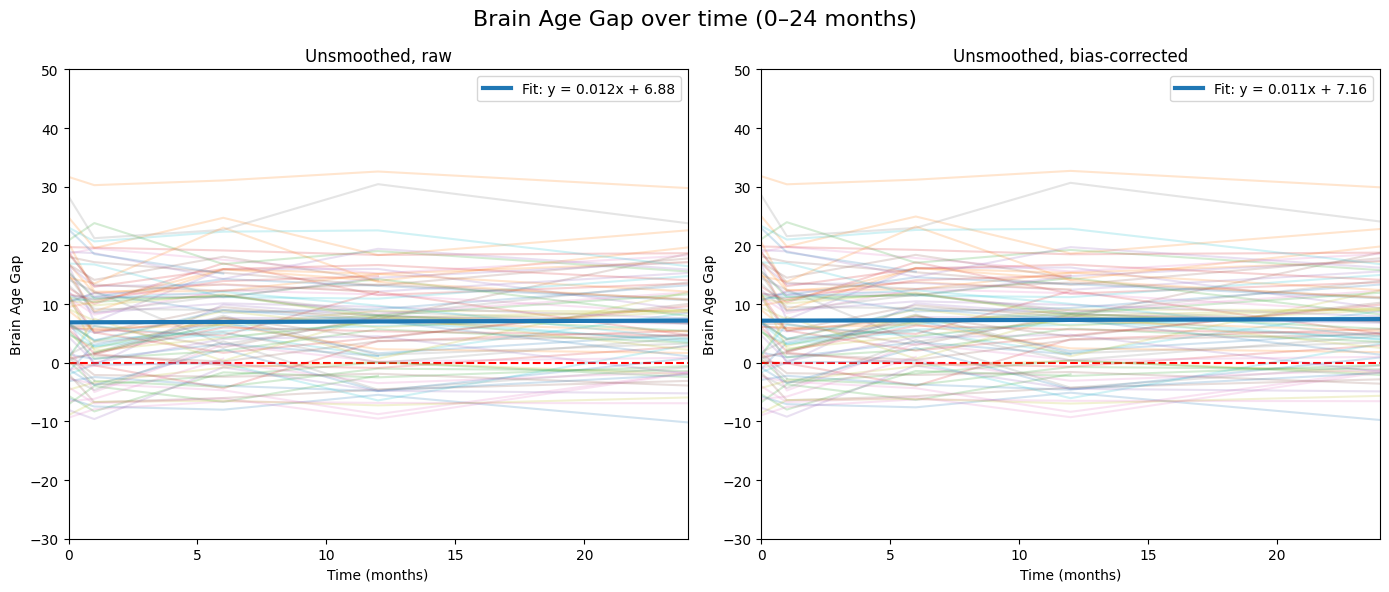

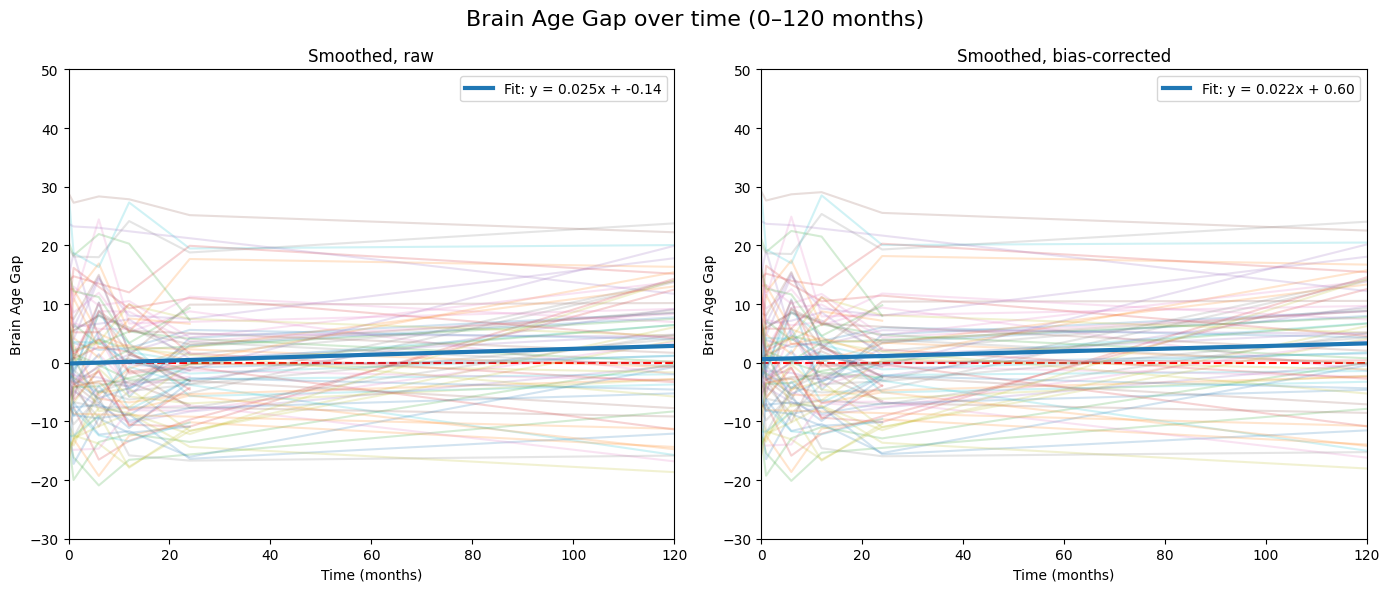

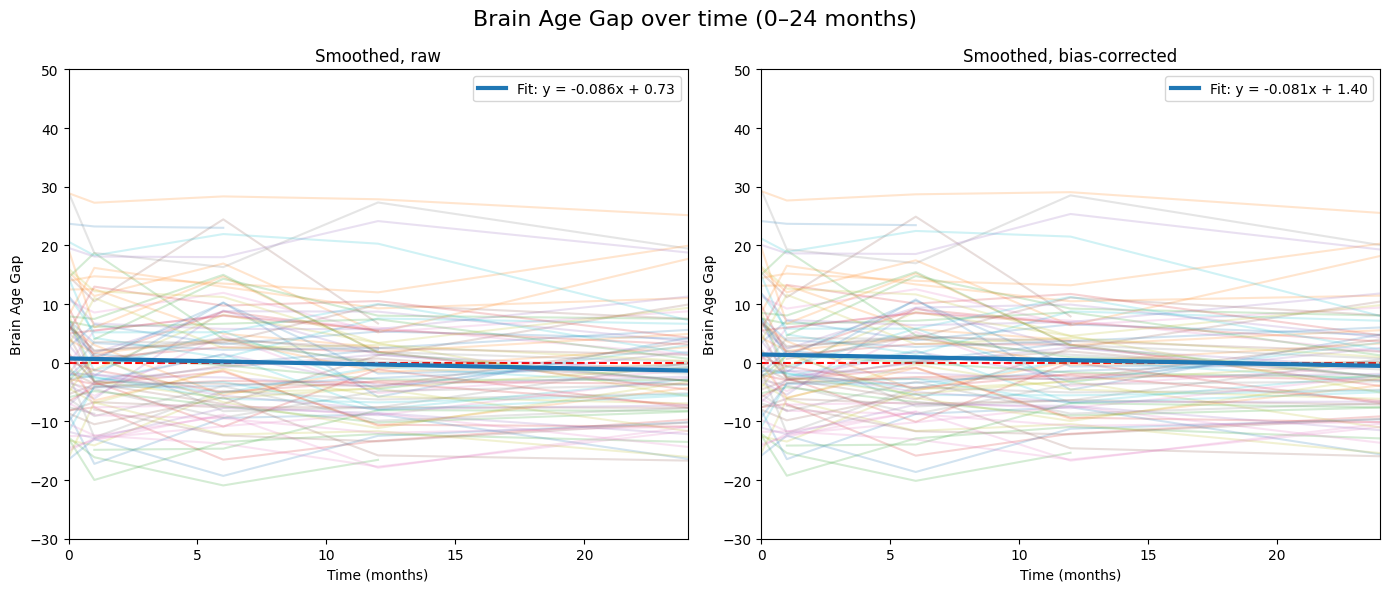

In [14]:
# Plot raw BAG and bias-corrected BAG over time for the unsmoothed model
# The first plot includes the full 120-month follow-up, while the second focuses on 24 months.
plot_bag_over_time_flexible(df_long,cols=["brain_age_gap", "brain_age_gap_bc"],labels=["raw", "bias-corrected"],model_name="Unsmoothed",y_label="Brain Age Gap", time_limit=120)
plot_bag_over_time_flexible(df_long,cols=["brain_age_gap", "brain_age_gap_bc"],labels=["raw", "bias-corrected"],model_name="Unsmoothed",y_label="Brain Age Gap", time_limit=24)

# Plot raw BAG and bias-corrected BAG over time for the smoothed model
plot_bag_over_time_flexible(df_sm_long,cols=["brain_age_gap", "brain_age_gap_bc"],labels=["raw", "bias-corrected"],model_name="Smoothed",y_label="Brain Age Gap", time_limit=120)
plot_bag_over_time_flexible(df_sm_long,cols=["brain_age_gap", "brain_age_gap_bc"],labels=["raw", "bias-corrected"],model_name="Smoothed",y_label="Brain Age Gap", time_limit=24)

## Plot: Residual BAG over time

Residual BAG is calculated by regressing BAG on chronological age and using the residuals from this regression. This removes the linear association between BAG and age.

In [15]:
# Compute residual BAG from raw predictions
def compute_residual_BAG(df, bag_col, age_col, new_col_name):
    """
    Compute residual BAG by removing the linear effect of age from BAG.

    The function fits a linear regression:
        BAG = slope * age + intercept

    The residuals from this regression are then stored as a new column.
    A positive residual means that BAG is higher than expected for that age,
    while a negative residual means that BAG is lower than expected for that age.
    """
    
    
    # Select the columns needed for fitting the regression model
    tmp = df[[age_col, bag_col]].copy()

    # Convert values to numeric format and remove invalid values
    tmp[age_col] = pd.to_numeric(tmp[age_col], errors="coerce")
    tmp[bag_col] = pd.to_numeric(tmp[bag_col], errors="coerce")
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()
    
    # Fit linear regression between chronological age and BAG
    slope, intercept, *_ = stats.linregress(tmp[age_col], tmp[bag_col])
    
    # Calculate residual BAG for all rows in the original dataframe
    df[new_col_name] = (
        pd.to_numeric(df[bag_col], errors="coerce") -
        (slope * pd.to_numeric(df[age_col], errors="coerce") + intercept)
    )
    
    print(f"{new_col_name} created.")
    
    return df

In [16]:
# Compute residual BAG for the unsmoothed model
# This creates a new column called BAG_residual in df_long
df_long = compute_residual_BAG(df=df_long,bag_col="brain_age_gap",age_col="age",new_col_name="BAG_residual"
)

BAG_residual created.


In [17]:
# Compute residual BAG for the smoothed model
# This creates a new column called BAG_residual in df_sm_long
df_sm_long = compute_residual_BAG(df=df_sm_long,bag_col="brain_age_gap",age_col="age",new_col_name="BAG_residual"
)

BAG_residual created.


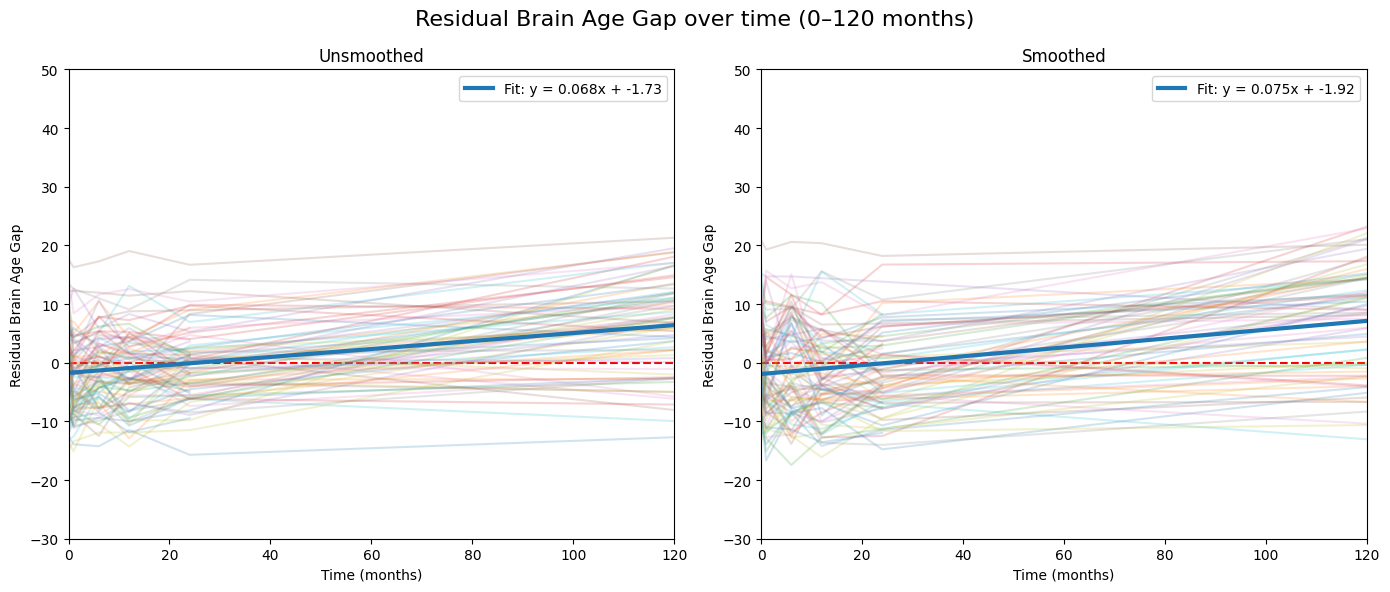

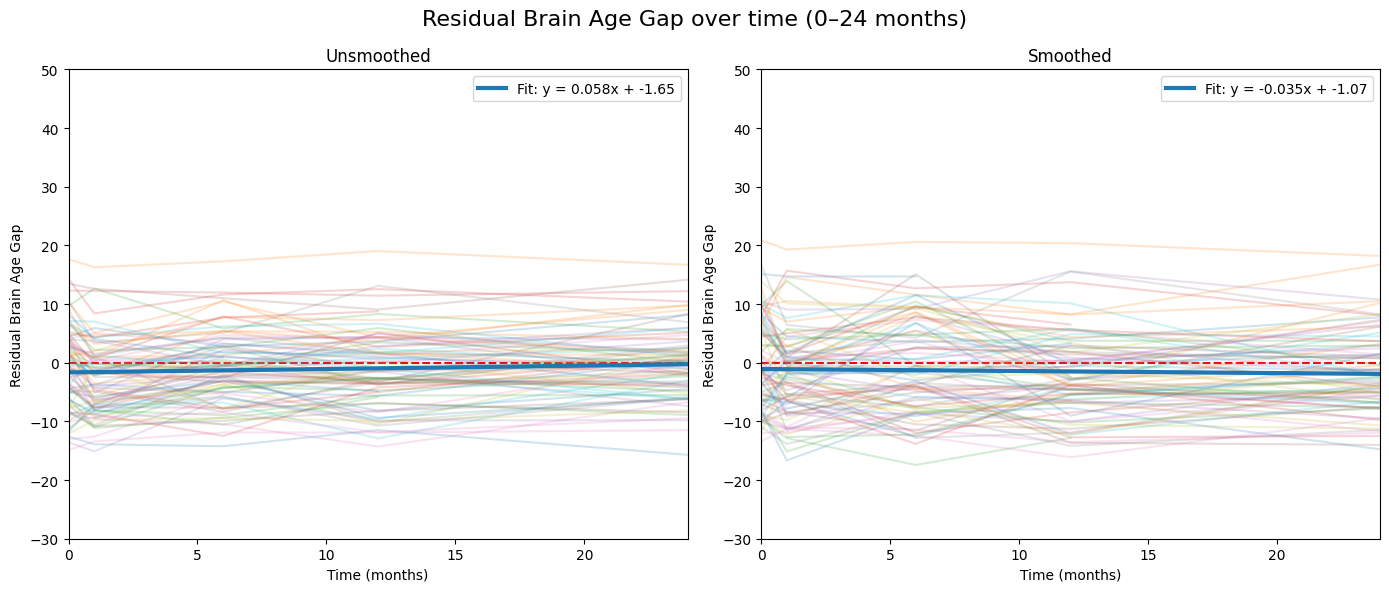

In [18]:
# Plot residual BAG over time for the unsmoothed and smoothed models
plot_bag_over_time_flexible(df_long,df_smooth=df_sm_long,cols=["BAG_residual"],y_label="Residual Brain Age Gap", time_limit=120)
plot_bag_over_time_flexible(df_long,df_smooth=df_sm_long,cols=["BAG_residual"],y_label="Residual Brain Age Gap", time_limit=24)

## Plot: Adjusted BAG over time

Adjusted BAG is calculated by removing the linear effects of age, sex, disease duration, and symptom duration from BAG.

This gives a BAG measure adjusted for several relevant demographic and clinical covariates.

In [19]:
# Calculate adjusted BAG for all sessions
# Adjusted BAG is defined as the residual from an OLS regression model.


# Unsmoothed model

# The model estimates how BAG depends on age, sex, disease duration, and symptom duration.
# The residuals represent the part of BAG not explained by these covariates.
model_unsmooth_raw = smf.ols('brain_age_gap ~ age + C(sex) + disease_duration + symptom_duration',data=df_long).fit()
df_long['BAG_adj'] = model_unsmooth_raw.resid

# Smoothed model
model_smooth_raw = smf.ols('brain_age_gap ~ age + C(sex) + disease_duration + symptom_duration',data=df_sm_long).fit()
df_sm_long['BAG_adj'] = model_smooth_raw.resid

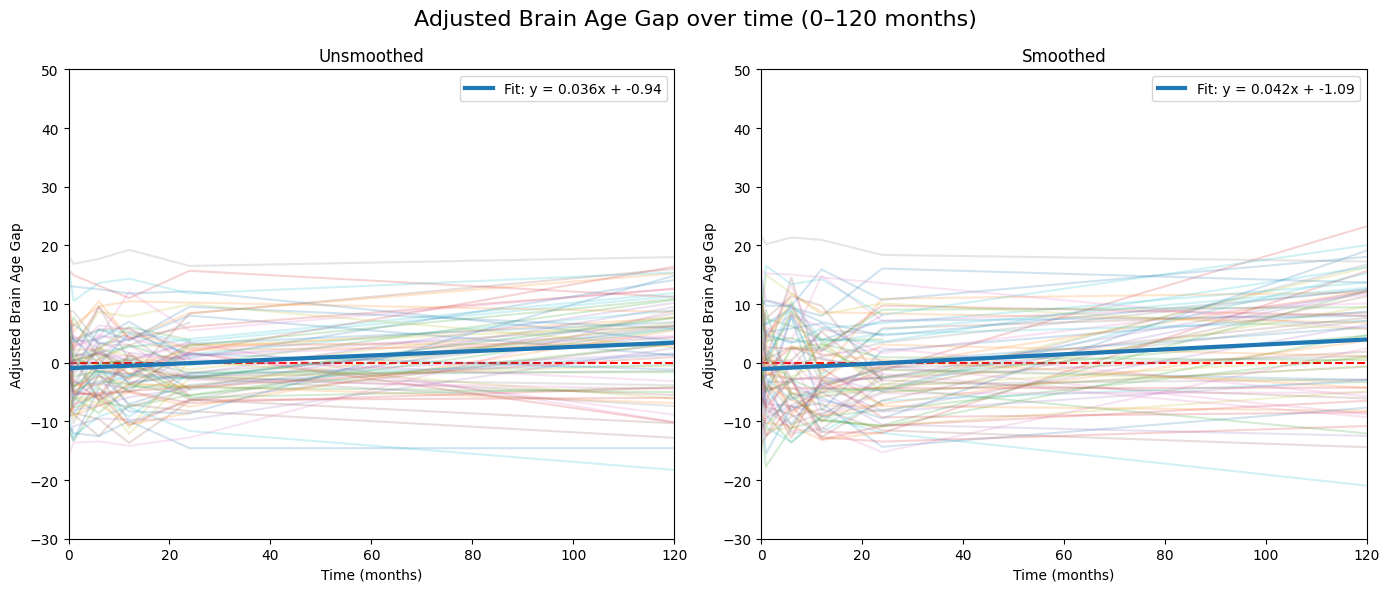

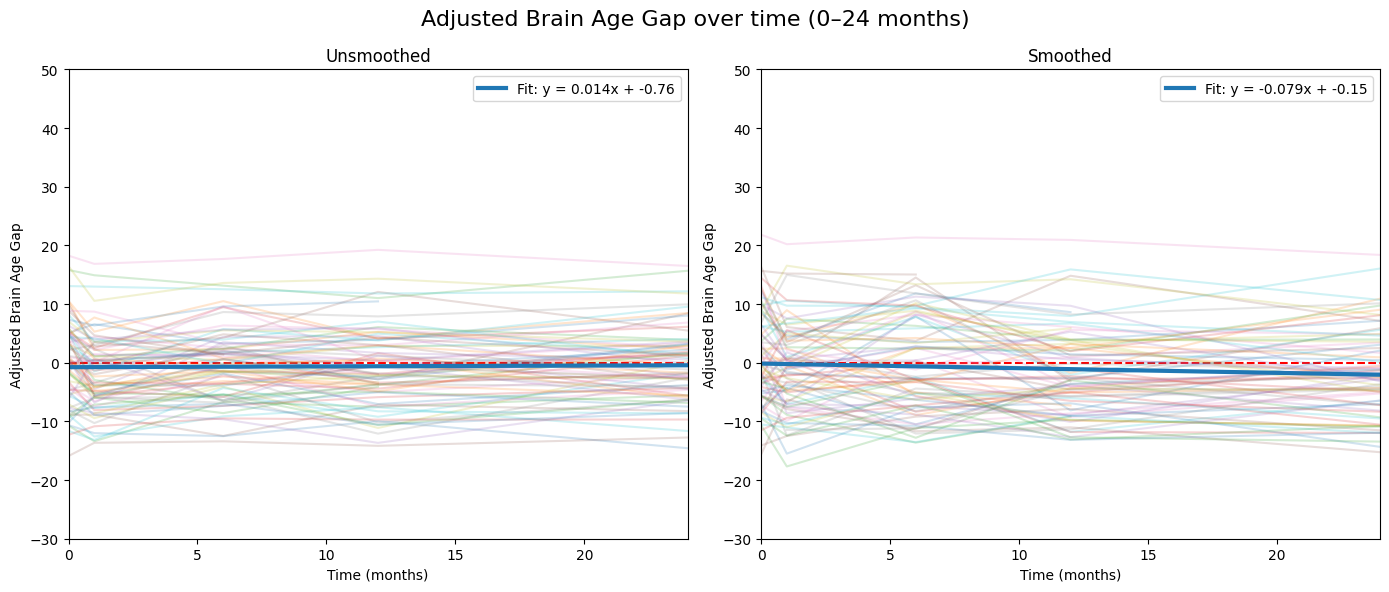

In [20]:
# Plot adjusted BAG over time for the unsmoothed and smoothed models
plot_bag_over_time_flexible(df_long,df_smooth=df_sm_long,cols=["BAG_adj"],y_label="Adjusted Brain Age Gap", time_limit=120)
plot_bag_over_time_flexible(df_long,df_smooth=df_sm_long,cols=["BAG_adj"],y_label="Adjusted Brain Age Gap", time_limit=24)

## Linear mixed models: BAG, residual BAG and adjusted BAG

Linear mixed-effects models are used to estimate whether each BAG measure changes significantly over time.

Linear mixed-effects models are fitted with a random intercept for each individual.

This accounts for repeated measurements from the same participant and allows each participant to have their own baseline level, while estimating one overall time effect across the cohort.

In [21]:
def fit_mixed_model(df, outcome_col, model_label):

    """
    Fit a linear mixed-effects model with time as predictor.

    Model structure:
        outcome_col ~ time + random intercept for participant

    The coefficient for time represents the estimated average monthly change
    in the selected BAG measure.
    """

    # Select relevant columns for the model
    tmp = df[['participant_id', 'time', outcome_col]].copy()

    # Remove rows with missing values in any model variable
    tmp = tmp.dropna().reset_index(drop=True)

    # Fit mixed-effects model with random intercept for participant
    model = smf.mixedlm(
        f"{outcome_col} ~ time",
        data=tmp,
        groups=tmp["participant_id"]
    ).fit()

    # Print model results
    print(f"\n===== {model_label} =====")
    print(model.summary())

    return model

In [22]:
# Fit mixed-effects models for raw BAG and bias-corrected BAG
# Models are fitted separately for unsmoothed and smoothed predictions
print("Brain Age Gap:")
# Unsmoothed model
model_bag_raw_uns = fit_mixed_model(df_long, "brain_age_gap", "Unsmoothed - BAG raw")
model_bag_bc_uns = fit_mixed_model(df_long, "brain_age_gap_bc", "Unsmoothed - BAG bias-corrected")

# Smoothed model
model_bag_raw_sm = fit_mixed_model(df_sm_long, "brain_age_gap", "Smoothed - BAG raw")
model_bag_bc_sm = fit_mixed_model(df_sm_long, "brain_age_gap_bc", "Smoothed - BAG bias-corrected")

Brain Age Gap:

===== Unsmoothed - BAG raw =====
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: brain_age_gap
No. Observations: 490     Method:             REML         
No. Groups:       91      Scale:              15.6807      
Min. group size:  1       Log-Likelihood:     -1506.4118   
Max. group size:  6       Converged:          Yes          
Mean group size:  5.4                                      
------------------------------------------------------------
              Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept      6.912     0.808  8.553  0.000   5.328   8.496
time           0.020     0.005  4.528  0.000   0.012   0.029
Group Var     54.668     2.420                              


===== Unsmoothed - BAG bias-corrected =====
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: brain_age_gap_bc
No. Observations:

Observation: For regular BAG, BAG increases over time for all model variants.

The estimated slopes correspond to approximately 0.22–0.24 years of BAG increase per year, depending on model and correction method.

The results from the analysis is in months, so the value is multiplied by 12 to see years of BAG per year.

In [23]:
# Fit mixed-effects models for residual BAG
print("Residual BAG:")
model_res_raw_uns = fit_mixed_model(df_long, "BAG_residual", "Unsmoothed - Residual BAG")

model_res_raw_sm = fit_mixed_model(df_sm_long, "BAG_residual", "Smoothed - Residual BAG")

Residual BAG:

===== Unsmoothed - Residual BAG =====
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: BAG_residual
No. Observations: 490     Method:             REML        
No. Groups:       91      Scale:              15.8095     
Min. group size:  1       Log-Likelihood:     -1482.0275  
Max. group size:  6       Converged:          Yes         
Mean group size:  5.4                                     
-----------------------------------------------------------
            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept   -1.680     0.610  -2.753  0.006  -2.876  -0.484
time         0.067     0.005  14.816  0.000   0.058   0.076
Group Var   29.193     1.360                               


===== Smoothed - Residual BAG =====
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: BAG_residual
No. Observations: 490     Method:       

Observation: Residual BAG increases with 0.8-0.88 years per year, for both models.

In [24]:
# Fit mixed-effects models for adjusted BAG
print("Adjusted BAG:")
model_adj_raw_uns = fit_mixed_model(df_long, "BAG_adj", "Unsmoothed - Adjusted BAG raw")

model_adj_raw_sm = fit_mixed_model(df_sm_long, "BAG_adj", "Smoothed - Adjusted BAG raw")

Adjusted BAG:

===== Unsmoothed - Adjusted BAG raw =====
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: BAG_adj   
No. Observations: 460     Method:             REML      
No. Groups:       82      Scale:              16.2952   
Min. group size:  1       Log-Likelihood:     -1397.7618
Max. group size:  6       Converged:          Yes       
Mean group size:  5.6                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.764    0.655 -1.165 0.244 -2.048  0.521
time           0.035    0.005  7.641 0.000  0.026  0.044
Group Var     30.967    1.482                           


===== Smoothed - Adjusted BAG raw =====
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: BAG_adj   
No. Observations: 460     Method:             REML      
No. Group

Observation: Adjusted BAG increases significantly over time (increases with 0.035-0.042 months = 0.42-0.5 years/year), for both models.

## Pearson correlation: BAG and time

Pearson correlations are calculated as an additional descriptive analysis of the relationship between BAG measures and time.

In [25]:
def pearson_ci(r, n):
    """
    Calculate a 95% confidence interval for a Pearson correlation coefficient.

    Fisher's z-transformation is used because the sampling distribution of r
    is not normally distributed, especially for stronger correlations.
    """
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96

    lo = z - z_crit * se
    hi = z + z_crit * se

    return np.tanh(lo), np.tanh(hi)

def compute_time_correlation(df, col, label):
    """
    Calculate Pearson correlation between time and a selected BAG measure.

    The function removes missing and infinite values before calculating:
    - Pearson correlation coefficient r
    - p-value
    - 95% confidence interval
    - sample size
    """

    # Select time and outcome column
    tmp = df[['time', col]].copy()

    # Remove missing and invalid values
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

    # Calculate Pearson correlation
    r, p = pearsonr(tmp['time'], tmp[col])
    n = len(tmp)

    # Calculate 95% confidence interval for r
    ci_lo, ci_hi = pearson_ci(r, n)

    # Print results
    print(f"\n===== {label} =====")
    print(f"r = {r:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], p = {p:.3e}, n = {n}")
    
    return r, p, ci_lo, ci_hi

In [26]:
# Correlation between time and raw/bias-corrected BAG
# Calculated separately for unsmoothed and smoothed models
compute_time_correlation(df_long, "brain_age_gap", "Unsmoothed - BAG raw")
compute_time_correlation(df_long, "brain_age_gap_bc", "Unsmoothed - BAG bias-corrected")

compute_time_correlation(df_sm_long, "brain_age_gap", "Smoothed - BAG raw")
compute_time_correlation(df_sm_long, "brain_age_gap_bc", "Smoothed - BAG bias-corrected")


===== Unsmoothed - BAG raw =====
r = 0.114, 95% CI [0.025, 0.200], p = 1.184e-02, n = 490

===== Unsmoothed - BAG bias-corrected =====
r = 0.107, 95% CI [0.019, 0.194], p = 1.738e-02, n = 490

===== Smoothed - BAG raw =====
r = 0.104, 95% CI [0.016, 0.191], p = 2.081e-02, n = 490

===== Smoothed - BAG bias-corrected =====
r = 0.094, 95% CI [0.006, 0.181], p = 3.683e-02, n = 490


(np.float64(0.0943404001480571),
 np.float64(0.03683048814652709),
 np.float64(0.0058056412110109295),
 np.float64(0.18140765624867983))

Observation: There is a weak positive trend between BAG and time for all model variants.

In [27]:
# Correlation between time and residual BAG
compute_time_correlation(df_long, "BAG_residual", "Unsmoothed - Residual BAG")

compute_time_correlation(df_sm_long, "BAG_residual", "Smoothed - Residual BAG")


===== Unsmoothed - Residual BAG =====
r = 0.386, 95% CI [0.308, 0.459], p = 8.090e-19, n = 490

===== Smoothed - Residual BAG =====
r = 0.364, 95% CI [0.284, 0.438], p = 9.395e-17, n = 490


(np.float64(0.36351280629078636),
 np.float64(9.394612212894803e-17),
 np.float64(0.2840771419252771),
 np.float64(0.4379922270721324))

Observation: Residual BAG shows a moderate to strong positive correlation with time for both the unsmoothed and smoothed models.

This supports the visual impression that residual BAG increases longitudinally.

In [28]:
# Correlation between time and adjusted BAG
# This evaluates whether BAG still increases with time after adjustment for age, sex,
# disease duration, and symptom duration.
compute_time_correlation(df_long, "BAG_adj", "Unsmoothed - Adjusted BAG")

compute_time_correlation(df_sm_long, "BAG_adj", "Smoothed - Adjusted BAG")


===== Unsmoothed - Adjusted BAG =====
r = 0.216, 95% CI [0.127, 0.302], p = 2.842e-06, n = 460

===== Smoothed - Adjusted BAG =====
r = 0.209, 95% CI [0.120, 0.295], p = 6.008e-06, n = 460


(np.float64(0.20925893818031904),
 np.float64(6.0082463248314054e-06),
 np.float64(0.12012838320126533),
 np.float64(0.2950429726313414))

Observation: Adjusted BAG shows a moderate positive correlation with time for both model variants, with strong statistical significance.

This indicates that the longitudinal increase remains visible even after adjustment for age, sex, disease duration, and symptom duration.

The pearson correlation was strongest for residual BAG.

In [29]:
# Save unsmoothed df
#df_long.to_csv("MS_longitudinal_unsmoothed.csv", index=False)

# Save smoothed df
#df_sm_long.to_csv("MS_longitudinal_smoothed.csv", index=False)